# k-Anonymity Impact on Model Performance
This notebook analyzes how different models behave under various levels of k-anonymity on the Adult dataset. It explores:
- Accuracy vs. k, LM, and MD
- F1-Score vs. k, LM, and MD
- Comparative robustness of models under increasing anonymity

# Adult Dataset Analysis

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")
df_adult = pd.read_csv("../results/adult_model_results_2.csv")
df_adult.head()

,k,LM,MD,model,accuracy,f1_0,f1_1,macro_avg_f1,macro_avg_precision,macro_avg_recall,precision_0,precision_1,recall_0,recall_1,weighted_avg_f1,weighted_avg_precision,weighted_avg_recall
0,1,0.0000,0,logistic,0.782552,0.841631,0.653167,0.747399,0.735304,0.795810,0.928833,0.541774,0.769397,0.822222,0.794699,0.832446,0.782552
1,2,31662.8056,106093,logistic,0.778809,0.843198,0.624689,0.733944,0.721222,0.765577,0.901554,0.540890,0.791938,0.739216,0.788784,0.811740,0.778809
2,4,34504.5889,148709,logistic,0.785970,0.850006,0.626527,0.738266,0.725588,0.764229,0.897183,0.553993,0.807542,0.720915,0.794354,0.811720,0.785970
3,8,40786.9258,171976,logistic,0.767578,0.833411,0.615716,0.724563,0.712903,0.760939,0.902476,0.523330,0.774166,0.747712,0.779200,0.808060,0.767578
4,16,47661.1028,205556,logistic,0.770182,0.838481,0.601805,0.720143,0.708553,0.745854,0.887839,0.529266,0.794322,0.697386,0.779543,0.798546,0.770182


### Accuracy vs. k (Adult Dataset)

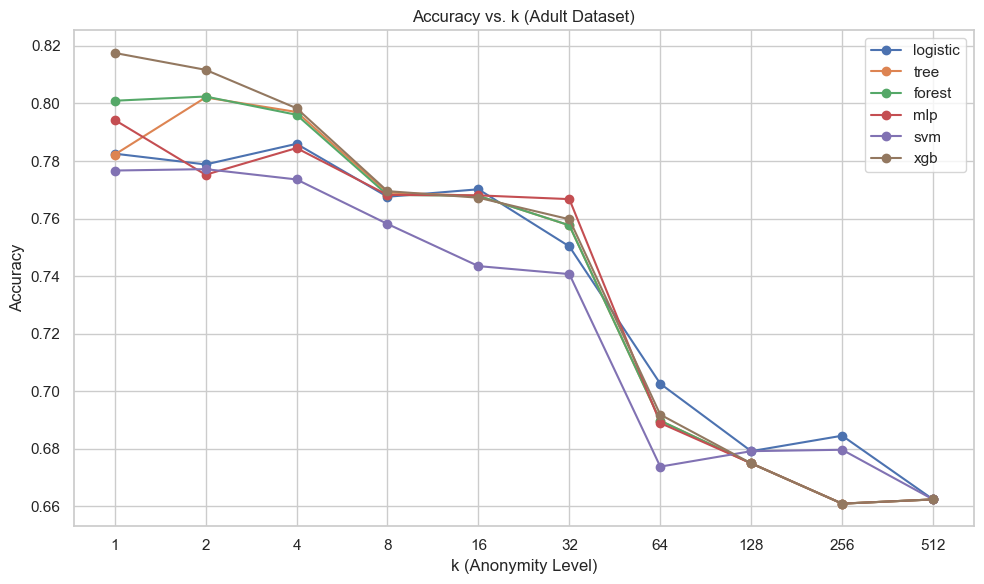

In [30]:
# Accuracy vs. k (Adult Dataset)
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
    subset = df_adult[df_adult['model'] == model]
    plt.plot(subset['k'], subset['accuracy'], marker='o', label=model)
plt.xscale('log', base=2)
plt.xticks(df_adult['k'].unique(), labels=df_adult['k'].unique())
plt.title('Accuracy vs. k (Adult Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Accuracy vs. LM (Adult Dataset)

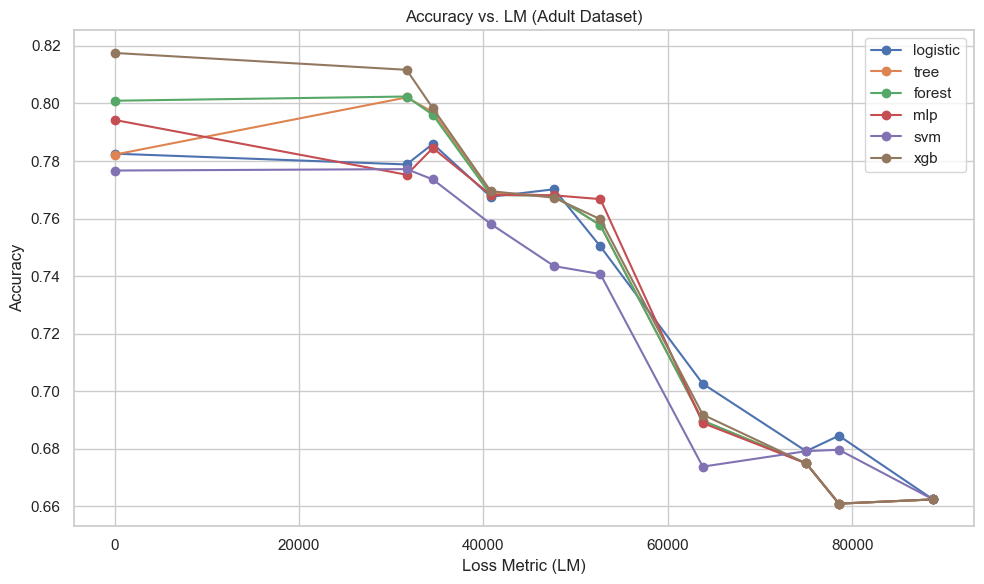

In [31]:
### Accuracy vs. LM (Adult Dataset)
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
	subset = df_adult[df_adult['model'] == model]
	plt.plot(subset['LM'], subset['accuracy'], marker='o', label=model)
plt.title('Accuracy vs. LM (Adult Dataset)')
plt.xlabel('Loss Metric (LM)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Accuracy vs. MD (Adult Dataset)

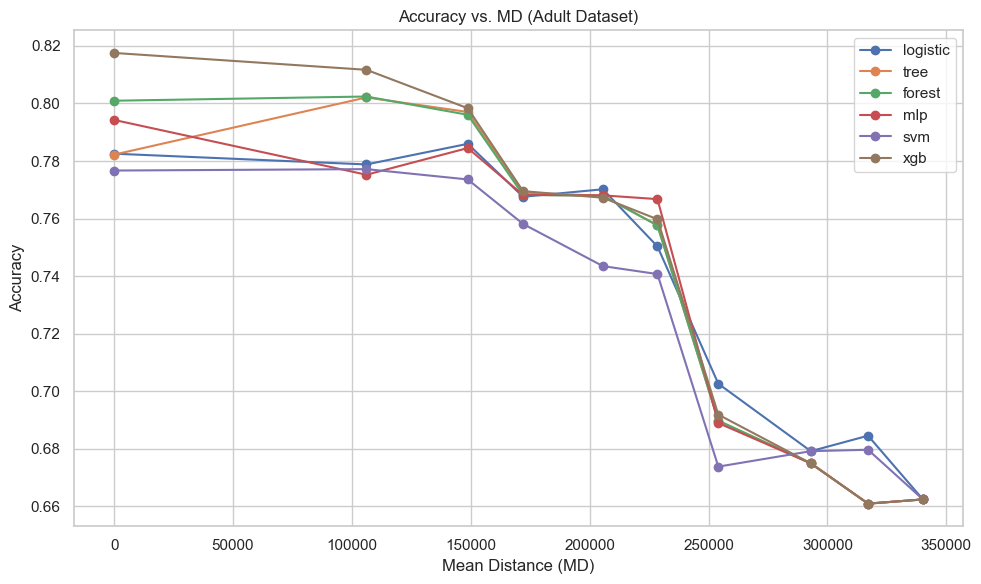

In [32]:
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
    subset = df_adult[df_adult['model'] == model]
    plt.plot(subset['MD'], subset['accuracy'], marker='o', label=model)
plt.title('Accuracy vs. MD (Adult Dataset)')
plt.xlabel('Mean Distance (MD)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro F1-Score vs. k (Adult Dataset)

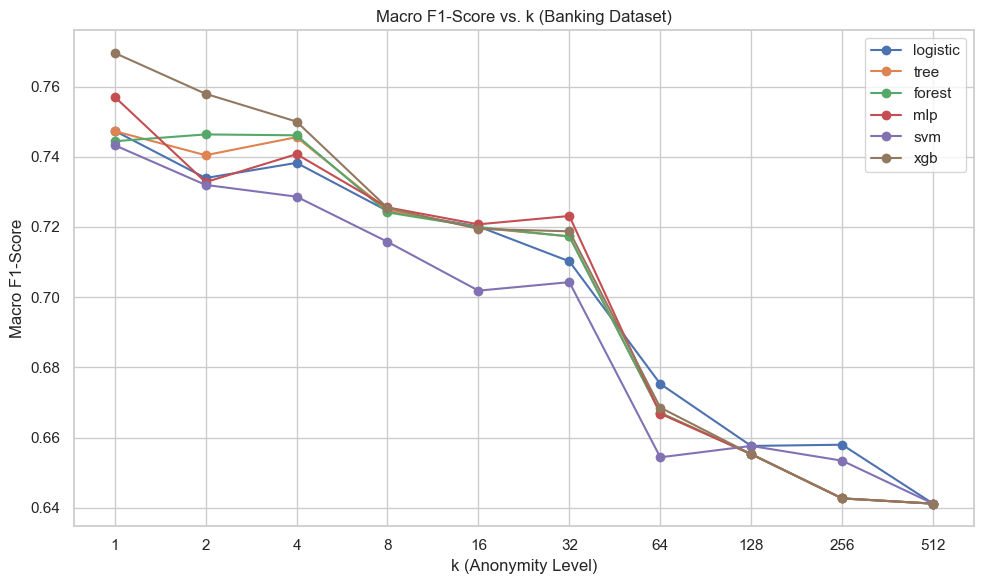

In [33]:
# Macro F1-Score vs. k
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
    subset = df_adult[df_adult['model'] == model]
    plt.plot(subset['k'], subset['macro_avg_f1'], marker='o', label=model)
plt.xscale('log', base=2)
plt.xticks(df_adult['k'].unique(), labels=df_adult['k'].unique())
plt.title('Macro F1-Score vs. k (Banking Dataset)')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro F1-Score vs. LM (Adult Dataset)

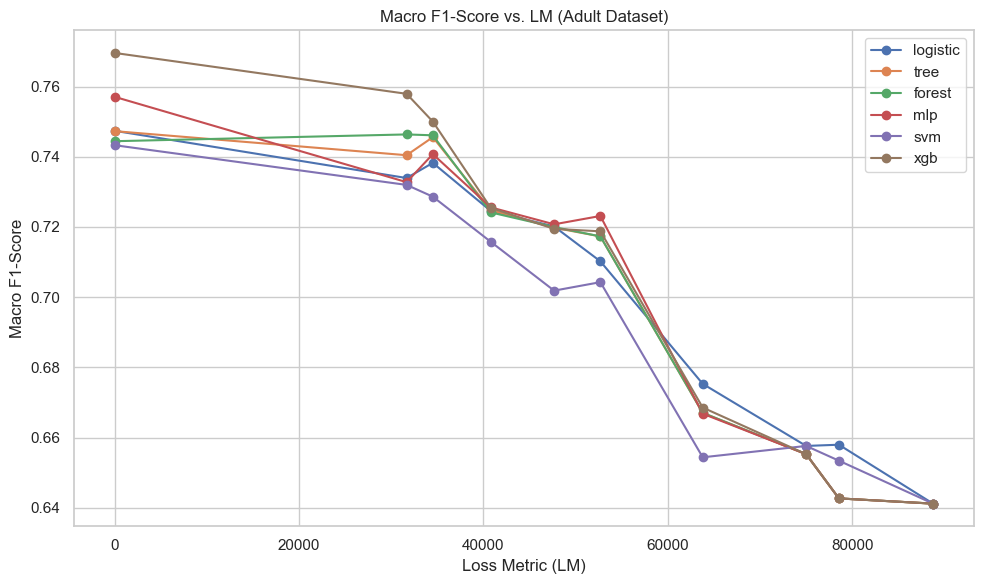

In [34]:
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
    subset = df_adult[df_adult['model'] == model]
    plt.plot(subset['LM'], subset['macro_avg_f1'], marker='o', label=model)
plt.title('Macro F1-Score vs. LM (Adult Dataset)')
plt.xlabel('Loss Metric (LM)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Macro F1-Score vs. MD (Adult Dataset)

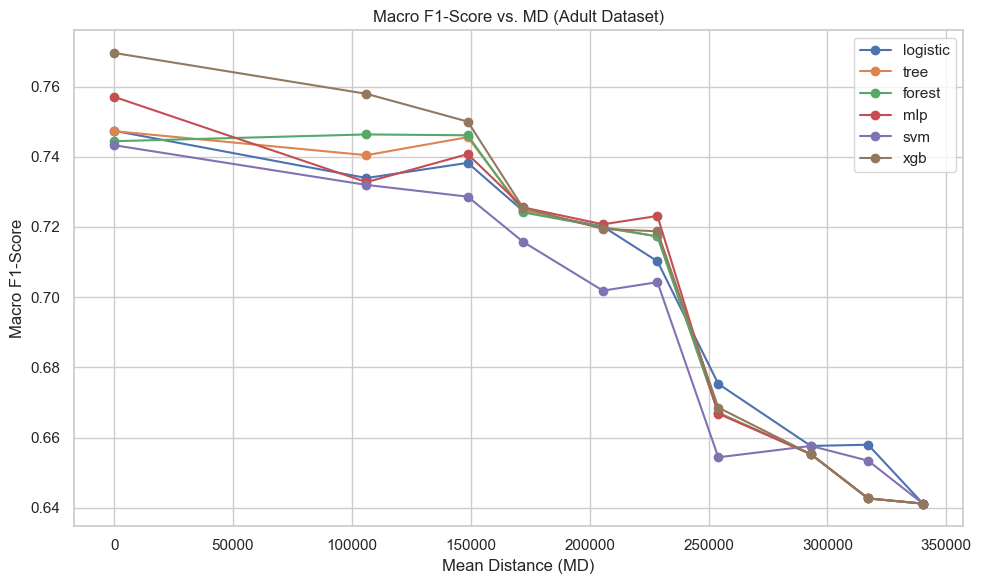

In [35]:
plt.figure(figsize=(10, 6))
for model in df_adult['model'].unique():
    subset = df_adult[df_adult['model'] == model]
    plt.plot(subset['MD'], subset['macro_avg_f1'], marker='o', label=model)
plt.title('Macro F1-Score vs. MD (Adult Dataset)')
plt.xlabel('Mean Distance (MD)')
plt.ylabel('Macro F1-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Percentage Change in Accuracy From Previous k Level

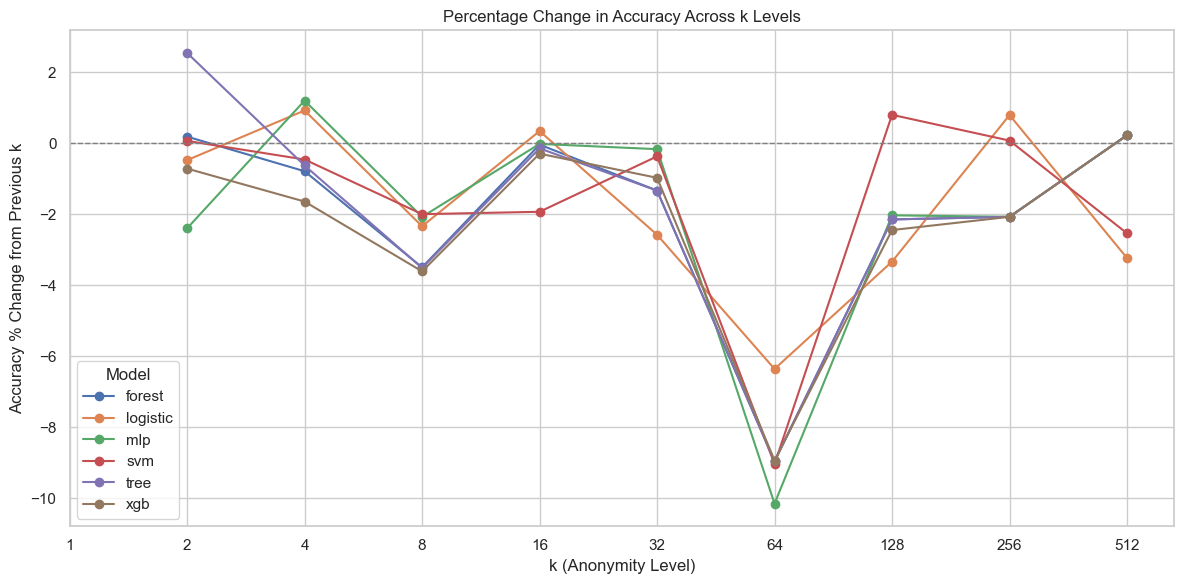

In [36]:
# Compute and plot percentage change in accuracy with respect to previous k level
df_sorted = df_adult.sort_values(by=["model", "k"])
df_sorted['accuracy_pct_change'] = df_sorted.groupby('model')['accuracy'].pct_change() * 100

# Plot percentage change for each model
plt.figure(figsize=(12, 6))
for model in df_sorted['model'].unique():
    subset = df_sorted[df_sorted['model'] == model]
    plt.plot(subset['k'], subset['accuracy_pct_change'], marker='o', label=model)

plt.xscale('log', base=2)
plt.xticks(df_adult['k'].unique(), labels=df_adult['k'].unique())
plt.axhline(0, linestyle='--', color='gray', linewidth=1)
plt.title('Percentage Change in Accuracy Across k Levels')
plt.xlabel('k (Anonymity Level)')
plt.ylabel('Accuracy % Change from Previous k')
plt.legend(title='Model')
plt.grid(True)
plt.tight_layout()
plt.show()

### Model Robustness Comparison

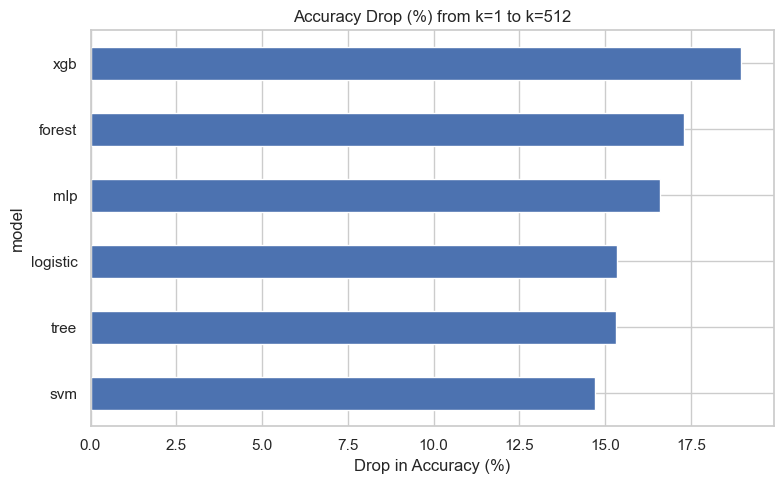

In [37]:
# Robustness analysis: accuracy decline rate from k=1 to k=1024
robustness = df_adult[df_adult['k'] == 1][['model', 'accuracy']].set_index('model')
robustness.columns = ['acc_k1']
acc_k512 = df_adult[df_adult['k'] == 512][['model', 'accuracy']].set_index('model')
acc_k512.columns = ['acc_k512']
robustness = robustness.join(acc_k512)
robustness['drop (%)'] = (robustness['acc_k1'] - robustness['acc_k512']) / robustness['acc_k1'] * 100
robustness.sort_values('drop (%)', inplace=True)
robustness.plot(kind='barh', y='drop (%)', legend=False, figsize=(8, 5), title='Accuracy Drop (%) from k=1 to k=512')
plt.xlabel('Drop in Accuracy (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

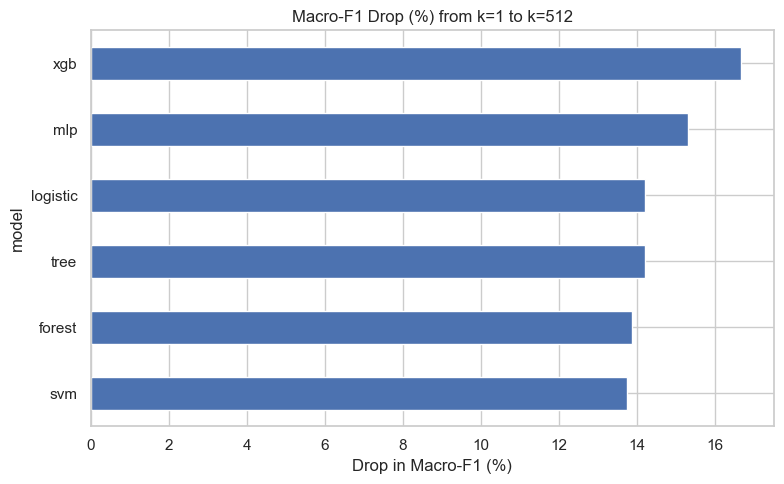

In [39]:
# Robustness analysis: macro-f1 decline rate from k=1 to k=1024
robustness = df_adult[df_adult['k'] == 1][['model', 'macro_avg_f1']].set_index('model')
robustness.columns = ['f1_k1']
f1_k512 = df_adult[df_adult['k'] == 512][['model', 'macro_avg_f1']].set_index('model')
f1_k512.columns = ['f1_k512']
robustness = robustness.join(f1_k512)
robustness['drop (%)'] = (robustness['f1_k1'] - robustness['f1_k512']) / robustness['f1_k1'] * 100
robustness.sort_values('drop (%)', inplace=True)
robustness.plot(kind='barh', y='drop (%)', legend=False, figsize=(8, 5), title='Macro-F1 Drop (%) from k=1 to k=512')
plt.xlabel('Drop in Macro-F1 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()